<a href="https://colab.research.google.com/github/JhonC07/ChallengeTelecomXAnalisisEvasionClientesAlura/blob/main/ChallengeAnalisisEvasionClientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Extracción de Datos (ETL - Extract)

In [10]:
import pandas as pd

# 1.1. Aplanar columnas anidadas
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

# 1.2. Eliminar columnas originales con diccionarios
df = df.drop(columns=['customer', 'phone', 'internet', 'account'])

# 1.3. Unir todo nuevamente
df = pd.concat([df, customer_df, phone_df, internet_df, account_df], axis=1)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#2. Conociendo el conjunto de datos

In [11]:
df.info()
df.dtypes
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

#3. Comprobación de incoherencias en los datos

In [12]:
##3.1. Valores Nulos

df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [15]:
##3.2. Valores duplicados
df.duplicated(subset='customerID').sum()

np.int64(0)

In [14]:
##3.3. Valores únicos
df['Churn'].unique()
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

#4. Manejo de inconsistencias

In [17]:
##4.1. Verificar
if df['Charges.Total'].dtype == 'object':
    df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

In [18]:
##4.2. Evaluar impacto de la conversión
nulos_total = df['Charges.Total'].isnull().sum()

if nulos_total > 0:
    print(f"Se generaron {nulos_total} valores nulos en Charges.Total tras la conversión.")
else:
    print("No se generaron valores nulos tras la conversión.")

Se generaron 11 valores nulos en Charges.Total tras la conversión.


In [21]:
##4.3. Clientes recien ingresados
df[df['Charges.Total'].isnull()][['tenure', 'Charges.Monthly']]

,tenure,Charges.Monthly
975,0,56.05
1775,0,20.00
1955,0,61.90
2075,0,19.70
2232,0,20.25
2308,0,25.35
2930,0,73.35
3134,0,25.75
3203,0,52.55
4169,0,80.85


In [22]:
##4.4. Corrección
df.loc[
    (df['Charges.Total'].isnull()) & (df['tenure'] == 0),
    'Charges.Total'
] = 0

In [23]:
##4.5. Validar nuevamente
df['Charges.Total'].isnull().sum()

np.int64(0)

In [29]:
##4.6. Versión Automática
import numpy as np
import pandas as pd

def limpiar_charges_total(df):

    print("🔎 Iniciando validación de Charges.Total...\n")

    ### 4.6.1. Convertir a numérico si es necesario
    if df['Charges.Total'].dtype == 'object':
        df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
        print("✔ Charges.Total convertido a numérico.")

    # 4.6.2. Contar nulos generados
    nulos = df['Charges.Total'].isnull().sum()
    print(f"📊 Valores nulos detectados: {nulos}")

    # 4.6.3. Corregir nulos donde tenure = 0
    condicion = (df['Charges.Total'].isnull()) & (df['tenure'] == 0)
    corregidos = condicion.sum()

    if corregidos > 0:
        df.loc[condicion, 'Charges.Total'] = 0
        print(f"✔ Se corrigieron {corregidos} registros con tenure = 0.")

    # 4.6.4. Verificar inconsistencias matemáticas
    diferencia = np.abs(df['Charges.Total'] - (df['Charges.Monthly'] * df['tenure']))
    inconsistencias = (diferencia > 1).sum()

    print(f"⚠ Inconsistencias detectadas en cálculo Total ≈ Monthly × Tenure: {inconsistencias}")

    print("\n✅ Validación final completada.")

    return df

In [40]:
##4.7. Limpiar datos
df = limpiar_charges_total(df)

🔎 Iniciando validación de Charges.Total...

📊 Valores nulos detectados: 0
⚠ Inconsistencias detectadas en cálculo Total ≈ Monthly × Tenure: 6491

✅ Validación final completada.


#5. Creación de la Columna Cuentas_Diarias

Calcular el valor promedio diario pagado por cada cliente a partir de Cuentas_Diarias = (Charges.Monthly​/30)

Esto permite:

* Analizar sensibilidad al precio
* Comparar churn por costo diario
* Generar mejores visualizaciones
* Facilitar modelos predictivos

In [31]:
##Validación previa (Buenas prácticas)
### Asegurar que Charges.Monthly sea numérica y no tenga valores negativos.
df['Charges.Monthly'].dtype
df['Charges.Monthly'].isnull().sum()

np.int64(0)

In [32]:
##Creación automática y segura
df['cuentas_diarias'] = df['Charges.Monthly'] / 30

In [33]:
###Validación atumatica
def crear_cuentas_diarias(df):

    print("🔎 Validando Charges.Monthly...")

    # Verificar tipo
    if df['Charges.Monthly'].dtype == 'object':
        df['Charges.Monthly'] = pd.to_numeric(df['Charges.Monthly'], errors='coerce')
        print("✔ Charges.Monthly convertido a numérico.")

    # Verificar nulos
    nulos = df['Charges.Monthly'].isnull().sum()
    if nulos > 0:
        print(f"⚠ Se detectaron {nulos} valores nulos en Charges.Monthly.")

    # Crear columna
    df['cuentas_diarias'] = df['Charges.Monthly'] / 30

    print("✅ Columna cuentas_diarias creada correctamente.")

    return df

In [34]:
###Uso
df = crear_cuentas_diarias(df)

🔎 Validando Charges.Monthly...
✅ Columna cuentas_diarias creada correctamente.


In [35]:
##Validación posterior
df[['Charges.Monthly', 'cuentas_diarias']].head()
df['cuentas_diarias'].describe()


,cuentas_diarias
count,7267.000000
mean,2.157337
std,1.004319
min,0.608333
25%,1.180833
50%,2.343333
75%,2.995833
max,3.958333


In [36]:
##Primer análisis estratégico
df.groupby('Churn')['cuentas_diarias'].mean()

,cuentas_diarias
Churn,
,2.113743
No,2.042171
Yes,2.481378


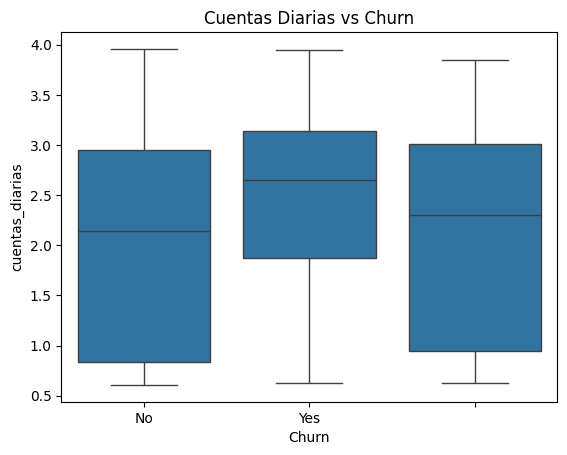

In [37]:
##Visualización datos
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Churn', y='cuentas_diarias', data=df)
plt.title('Cuentas Diarias vs Churn')
plt.show()

#6. Estandarización y Transformación de Datos
* Convertir variables categóricas binarias a formato numérico (0/1)
* Renombrar columnas para mayor claridad
* Preparar el dataset para análisis estadístico y modelos predictivos

In [38]:
##6.1. Estandarizar variables binarias (Yes/No → 1/0)

def convertir_binarias(df):

    columnas_binarias = [
        'Churn',
        'Partner',
        'Dependents',
        'PhoneService',
        'PaperlessBilling'
    ]

    for col in columnas_binarias:
        if col in df.columns:
            df[col] = df[col].map({'yes': 1, 'no': 0})

    print("✅ Variables binarias convertidas a formato numérico.")

    return df

In [39]:
###6.1.1. Uso
df = convertir_binarias(df)

✅ Variables binarias convertidas a formato numérico.


In [41]:
##6.2. Convertir género a binario

df['gender'] = df['gender'].map({'male': 1, 'female': 0})

In [42]:
##6.3. Renombrar columnas para claridad
df.rename(columns={
    'customerID': 'customer_id',
    'tenure': 'months_active',
    'Charges.Monthly': 'monthly_charges',
    'Charges.Total': 'total_charges'
}, inplace=True)

In [43]:
##6.4. Estandarizar nombres de columnas automáticamente
df.columns = df.columns.str.lower().str.replace('.', '_')

In [46]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customer_id                            7267 non-null   object 
 1   churn                                  0 non-null      float64
 2   gender                                 0 non-null      float64
 3   seniorcitizen                          7267 non-null   int64  
 4   partner                                0 non-null      float64
 5   dependents                             0 non-null      float64
 6   months_active                          7267 non-null   int64  
 7   phoneservice                           0 non-null      float64
 8   multiplelines                          7267 non-null   object 
 9   onlinesecurity                         7267 non-null   object 
 10  onlinebackup                           7267 non-null   object 
 11  devi

,customer_id,churn,gender,seniorcitizen,partner,dependents,months_active,phoneservice,multiplelines,onlinesecurity,...,total_charges,inconsistencia_total,cuentas_diarias,contract_One year,contract_Two year,internetservice_Fiber optic,internetservice_No,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,0002-ORFBO,NaN,NaN,0,NaN,NaN,9,NaN,No,No,...,593.30,True,2.186667,True,False,False,False,False,False,True
1,0003-MKNFE,NaN,NaN,0,NaN,NaN,9,NaN,Yes,No,...,542.40,True,1.996667,False,False,False,False,False,False,True
2,0004-TLHLJ,NaN,NaN,0,NaN,NaN,4,NaN,No,No,...,280.85,True,2.463333,False,False,True,False,False,True,False
3,0011-IGKFF,NaN,NaN,1,NaN,NaN,13,NaN,No,No,...,1237.85,True,3.266667,False,False,True,False,False,True,False
4,0013-EXCHZ,NaN,NaN,1,NaN,NaN,3,NaN,No,No,...,267.40,True,2.796667,False,False,True,False,False,False,True
